In [2211]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [2212]:
df = pd.read_csv('datasets/train.csv',usecols=['Age','Fare','Survived'])

In [2213]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [2214]:
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [2215]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [2216]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [2217]:
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [2218]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [2219]:
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [2220]:
mask_train = X_train['Age_imputed'].isnull()
mask_test = X_test['Age_imputed'].isnull()

X_train.loc[mask_train,'Age_imputed']=X_train['Age'].dropna().sample(mask_train.sum()).values

X_test.loc[mask_test, 'Age_imputed'] = X_train['Age'].dropna().sample(mask_test.sum()).values

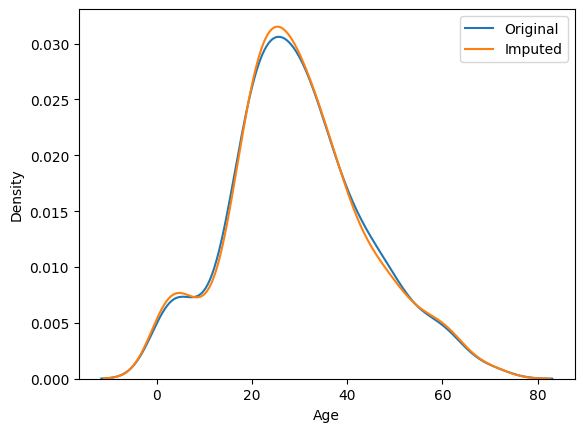

In [2221]:
sns.kdeplot(X_train['Age'], label='Original')
sns.kdeplot(X_train['Age_imputed'], label='Imputed')
plt.legend()
plt.show()

In [2222]:
print("Age original", X_train['Age'].var())
print("Age imputed", X_train['Age_imputed'].var())

Age original 204.34951339046142
Age imputed 206.64223071299324


In [2223]:
X_train[['Fare','Age','Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,54.189246
Age,71.512440,204.349513,204.349513
Age_imputed,54.189246,204.349513,206.642231


<Axes: >

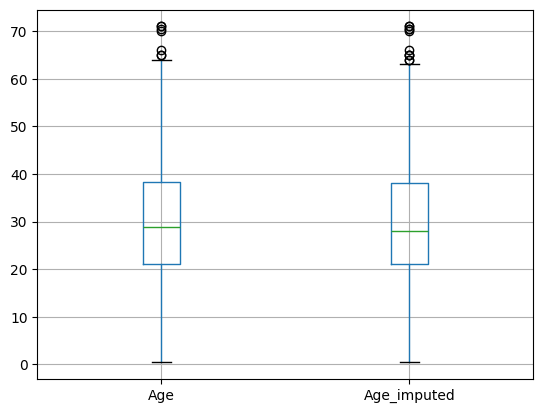

In [2224]:
X_train[['Age','Age_imputed']].boxplot()

In [2225]:
data = pd.read_csv('datasets/housing_train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [2226]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [2227]:
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [2228]:
X = data
y = data['SalePrice']

In [2229]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [2230]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [2231]:
X_train

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
455,TA,TA,175500,TA,TA
863,NaN,TA,132500,TA,NaN
504,Fa,TA,147000,TA,Fa
1413,Gd,TA,257000,TA,Gd
1389,Gd,TA,131000,TA,Gd
...,...,...,...,...,...
466,Po,TA,167000,TA,Po
299,Gd,TA,158500,TA,Gd
493,Fa,TA,155000,TA,Fa
527,Gd,TA,446261,TA,Gd


In [2232]:
X_train.columns

Index(['FireplaceQu', 'GarageQual', 'SalePrice', 'GarageQual_imputed',
       'FireplaceQu_imputed'],
      dtype='object')

In [2233]:
mask_train1 = X_train['GarageQual_imputed'].isnull()
mask_train2 = X_train['FireplaceQu_imputed'].isnull()

mask_test1 = X_test['GarageQual_imputed'].isnull()
mask_test2 = X_test['FireplaceQu_imputed'].isnull()

X_train.loc[mask_train1,'GarageQual_imputed']=X_train['GarageQual'].dropna().sample(mask_train1.sum()).values
X_test.loc[mask_test1,'GarageQual_imputed']=X_test['GarageQual'].dropna().sample(mask_test1.sum()).values

X_train.loc[mask_train2,'FireplaceQu_imputed']=X_train['FireplaceQu'].dropna().sample(mask_train2.sum()).values
X_test.loc[mask_test2,'FireplaceQu_imputed']=X_test['FireplaceQu'].dropna().sample(mask_test2.sum()).values

In [2234]:
temp = pd.concat([
    X_train['GarageQual'].value_counts()/len(X_train['GarageQual'].dropna()),
    X_train['GarageQual_imputed'].value_counts()/len(X_train['GarageQual_imputed'].dropna())
], axis=1)
temp.columns=['Original', 'imputed']

In [2235]:
temp

,Original,imputed
TA,0.951043,0.952911
Fa,0.037171,0.035959
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [2238]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [2239]:
temp

,original,imputed
Gd,0.494272,0.491438
TA,0.412439,0.416096
Fa,0.040917,0.039384
Po,0.027823,0.028253
Ex,0.024550,0.024829


In [2240]:
from sklearn.impute import MissingIndicator,SimpleImputer

In [2241]:
df = pd.read_csv('datasets/train.csv',usecols=['Age','Fare','Survived'])

In [2242]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [2243]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [2244]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [2245]:
X_train.head()

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458


In [2246]:
si = SimpleImputer()
X_train_trf = si.fit_transform(X_train)
X_test_trf = si.transform(X_test)

In [2247]:
X_train_trf

array([[ 40.        ,  27.7208    ],
       [  4.        ,  16.7       ],
       [ 47.        ,   9.        ],
       ...,
       [ 71.        ,  49.5042    ],
       [ 29.78590426, 221.7792    ],
       [ 29.78590426,  25.925     ]], shape=(712, 2))

In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(X_train_trf, y_train)
y_pred = clf.predict(X_test_trf)

In [2249]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.6145251396648045

In [2250]:
mi = MissingIndicator()

mi.fit(X_train)

,"missing_values missing_values: int, float, str, np.nan or None, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`should be set to `np.nan`, since `pd.NA` will be converted to `np.nan`.",nan
,"features features: {'missing-only', 'all'}, default='missing-only'Whether the imputer mask should represent all or a subset offeatures.- If `'missing-only'` (default), the imputer mask will only represent features containing missing values during fit time.- If `'all'`, the imputer mask will represent all features.",'missing-only'
,"sparse sparse: bool or 'auto', default='auto'Whether the imputer mask format should be sparse or dense.- If `'auto'` (default), the imputer mask will be of same type as input.- If `True`, the imputer mask will be a sparse matrix.- If `False`, the imputer mask will be a numpy array.",'auto'
,"error_on_new error_on_new: bool, default=TrueIf `True`, :meth:`transform` will raise an error when there arefeatures with missing values that have no missing values in:meth:`fit`. This is applicable only when `features='missing-only'`.",True


In [2251]:
mi.features_

array([0])

In [2252]:
X_train_missing = mi.transform(X_train)
X_test_missing = mi.transform(X_test)

In [2255]:
X_train_missing

array([[False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [

In [2256]:
X_train['age_na'] = X_train_missing

In [2257]:
X_test['age_na'] = X_test_missing

In [2259]:
X_train

,Age,Fare,age_na
30,40.0,27.7208,False
10,4.0,16.7000,False
873,47.0,9.0000,False
182,9.0,31.3875,False
876,20.0,9.8458,False
...,...,...,...
534,30.0,8.6625,False
584,NaN,8.7125,True
493,71.0,49.5042,False
527,NaN,221.7792,True


In [2262]:
si = SimpleImputer(add_indicator=True)
X_train_trf2 = si.fit_transform(X_train)
X_test_trf2 = si.transform(X_test)

In [2263]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(X_train_trf2, y_train)
y_pred = clf.predict(X_test_trf2)
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.6312849162011173